In [3]:
#Importing The Libraries
import pandas as pd    #For creating our dataset df.
import numpy as np     #Using the

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.cluster import DBSCAN
from xgboost import XGBClassifier

import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ahmedabad_fraud_stream_updated.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (12453, 26)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,Latitude,Longitude,Hotspot_Zone,City,Withdrawal_Window_Min
0,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,1311.86,OTP,0.7935,0,1,23.041824,72.573305,Ashram Road Financial Hub,Ahmedabad,28.0
1,TXN_49498,USER_4660,7.08,ATM Withdrawal,2023-02-25 03:43:00,45826.27,Tablet,London,Restaurants,0,...,1764.66,Biometric,0.5326,0,1,23.030541,72.556844,CG Road (Navrangpura),Ahmedabad,40.0
2,TXN_4144,USER_1584,34.25,ATM Withdrawal,2023-03-09 22:51:00,94392.35,Tablet,Tokyo,Clothing,0,...,550.38,Biometric,0.1347,1,0,23.032994,72.500232,NaN,Ahmedabad,NaN
3,TXN_38695,USER_6860,50.44,ATM Withdrawal,2023-08-06 08:22:00,19962.22,Laptop,London,Travel,0,...,3993.62,PIN,0.4582,0,0,22.965832,72.546509,NaN,Ahmedabad,NaN
4,TXN_6188,USER_6728,55.50,ATM Withdrawal,2023-07-20 03:10:00,89664.63,Laptop,London,Groceries,0,...,3721.54,OTP,0.5837,0,1,23.054151,72.513109,SG Highway (Sindhu Bhavan),Ahmedabad,21.0


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Columns:
['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Timestamp', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age', 'Transaction_Distance', 'Authentication_Method', 'Risk_Score', 'Is_Weekend', 'Fraud_Label', 'Latitude', 'Longitude', 'Hotspot_Zone', 'City', 'Withdrawal_Window_Min']

Data Types:
Transaction_ID                      str
User_ID                             str
Transaction_Amount              float64
Transaction_Type                    str
Timestamp                           str
Account_Balance                 float64
Device_Type                         str
Location                            str
Merchant_Category                   str
IP_Address_Flag                   int64
Previous_Fraudulent_Activity      int64
Daily_Transaction_Count           int64
Avg_Transaction_A

In [5]:
print(df["Fraud_Label"].value_counts())

print("\nFraud Percentage:")
print(df["Fraud_Label"].value_counts(normalize=True) * 100)

Fraud_Label
0    8407
1    4046
Name: count, dtype: int64

Fraud Percentage:
Fraud_Label
0    67.509837
1    32.490163
Name: proportion, dtype: float64


In [6]:
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

print(df["Timestamp"].dtype)

datetime64[us]


In [7]:
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek
df["Month"] = df["Timestamp"].dt.month

print(
    df[
        ["Timestamp", "Hour", "DayOfWeek", "Month"]
    ].head()
)

            Timestamp  Hour  DayOfWeek  Month
0 2023-12-07 00:31:00     0          3     12
1 2023-02-25 03:43:00     3          5      2
2 2023-03-09 22:51:00    22          3      3
3 2023-08-06 08:22:00     8          6      8
4 2023-07-20 03:10:00     3          3      7


In [8]:
print(df.groupby("Fraud_Label")["Withdrawal_Window_Min"].describe())

              count       mean       std   min   25%   50%   75%   max
Fraud_Label                                                           
0               0.0        NaN       NaN   NaN   NaN   NaN   NaN   NaN
1            4046.0  29.899654  8.948959  15.0  22.0  30.0  38.0  45.0


In [9]:
fraud_features = [
    "Transaction_Amount",
    "Account_Balance",
    "IP_Address_Flag",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Avg_Transaction_Amount_7d",
    "Failed_Transaction_Count_7d",
    "Card_Age",
    "Transaction_Distance",
    "Risk_Score",
    "Is_Weekend",
    "Latitude",
    "Longitude",
    "Hour",
    "DayOfWeek",
    "Month"
]

X = df[fraud_features]
y = df["Fraud_Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12453, 16)
y shape: (12453,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 9962
Testing samples: 2491


In [11]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [12]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1]


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1682
           1       1.00      1.00      1.00       809

    accuracy                           1.00      2491
   macro avg       1.00      1.00      1.00      2491
weighted avg       1.00      1.00      1.00      2491



In [14]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1682    0]
 [   0  809]]


In [15]:
fraud_probability = model.predict_proba(X_test)[:, 1]

print(fraud_probability[:20])

[9.9973005e-01 1.9265927e-04 2.3161089e-04 1.7902882e-04 1.5686055e-04
 1.7187955e-04 9.9962783e-01 2.1041188e-04 9.9974114e-01 1.8919716e-04
 1.7633053e-04 9.9969673e-01 1.5742486e-04 1.8805939e-04 1.4388029e-04
 1.7902882e-04 2.1950858e-04 2.2040095e-04 1.6407842e-04 9.9951899e-01]


In [16]:
importance = pd.Series(
    model.feature_importances_,
    index=fraud_features
).sort_values(ascending=False)

print(importance)

Failed_Transaction_Count_7d     0.602790
Risk_Score                      0.389275
Card_Age                        0.001896
Transaction_Distance            0.001526
Avg_Transaction_Amount_7d       0.001221
Hour                            0.000890
Daily_Transaction_Count         0.000444
Is_Weekend                      0.000432
DayOfWeek                       0.000389
Latitude                        0.000354
Account_Balance                 0.000273
Longitude                       0.000269
Month                           0.000241
IP_Address_Flag                 0.000000
Previous_Fraudulent_Activity    0.000000
Transaction_Amount              0.000000
dtype: float32


In [17]:
joblib.dump(model, "model.pkl")

print("model.pkl saved successfully!")

model.pkl saved successfully!


In [21]:
# ==========================================
# FINAL DBSCAN SPATIAL CLUSTERING
# ==========================================

# Select latitude and longitude
coordinates = df[["Latitude", "Longitude"]].dropna().copy()

# Convert latitude and longitude from degrees to radians
coords_rad = np.radians(coordinates)

# Create DBSCAN model
dbscan = DBSCAN(
    eps=0.00005,
    min_samples=5,
    metric="haversine"
)

# Perform clustering
labels = dbscan.fit_predict(coords_rad)

# Add cluster labels back to the original dataframe
df.loc[coordinates.index, "Cluster"] = labels

# Replace missing cluster values with -1
df["Cluster"] = df["Cluster"].fillna(-1).astype(int)

# ==========================================
# CLUSTER SUMMARY
# ==========================================

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("DBSCAN Results")
print("-------------------------")
print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

print("\nCluster Distribution:")
print(df["Cluster"].value_counts().sort_index())

DBSCAN Results
-------------------------
Number of clusters: 23
Number of noise points: 102

Cluster Distribution:
Cluster
-1       102
 0     12161
 1         9
 2        23
 3         7
 4        14
 5        17
 6         5
 7        11
 8         7
 9         6
 10        9
 11        9
 12        5
 13        6
 14        9
 15       13
 16        6
 17        7
 18        6
 19       10
 20        3
 21        3
 22        5
Name: count, dtype: int64


In [19]:
# Check how many clusters DBSCAN actually found

print("Unique cluster labels:")
print(sorted(df["Cluster"].unique()))

print("\nNumber of actual clusters:",
      df["Cluster"].nunique() - (1 if -1 in df["Cluster"].values else 0))

print("\nCluster distribution:")
print(df["Cluster"].value_counts().sort_index())

Unique cluster labels:
[np.int64(0)]

Number of actual clusters: 1

Cluster distribution:
Cluster
0    12453
Name: count, dtype: int64


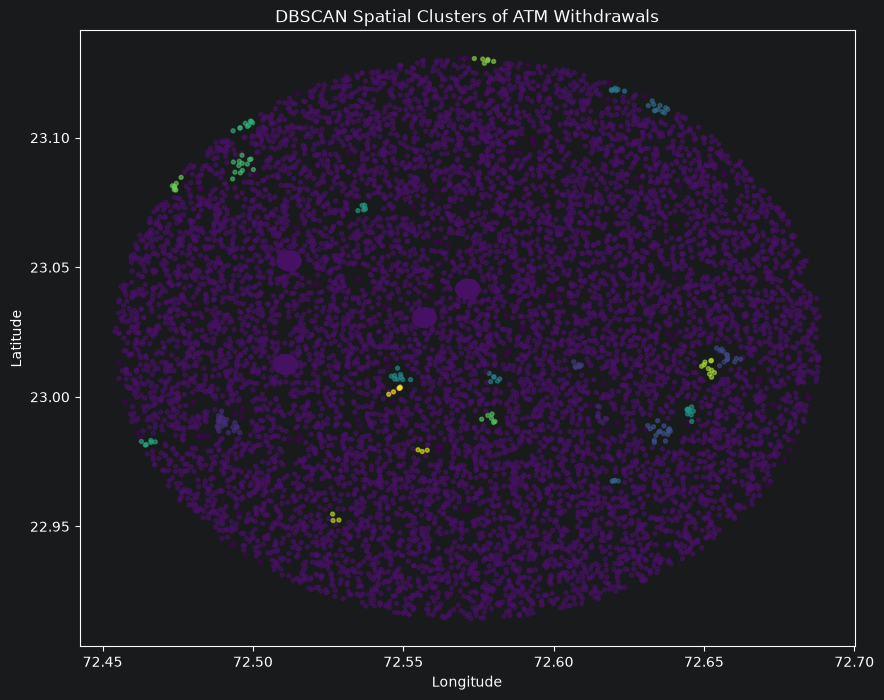

In [22]:
# ==========================================
# VISUALIZE DBSCAN CLUSTERS
# ==========================================

plt.figure(figsize=(10, 8))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["Cluster"],
    s=8,
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Spatial Clusters of ATM Withdrawals")

plt.show()

In [23]:
# ==========================================
# DBSCAN CLUSTER vs HOTSPOT ZONE
# ==========================================

cluster_zone = pd.crosstab(
    df["Cluster"],
    df["Hotspot_Zone"]
)

print(cluster_zone)

Hotspot_Zone  Ashram Road Financial Hub  CG Road (Navrangpura)  \
Cluster                                                          
0                                   653                    740   

Hotspot_Zone  Prahlad Nagar Corporate Rd  SG Highway (Sindhu Bhavan)  
Cluster                                                               
0                                    721                         718  


In [24]:
# ==========================================
# PREPARE HOTSPOT DATA
# ==========================================

zone_df = df.dropna(subset=["Hotspot_Zone"]).copy()

print("Hotspot-labelled rows:", len(zone_df))

print("\nHotspot distribution:")
print(zone_df["Hotspot_Zone"].value_counts())

Hotspot-labelled rows: 2832

Hotspot distribution:
Hotspot_Zone
CG Road (Navrangpura)         740
Prahlad Nagar Corporate Rd    721
SG Highway (Sindhu Bhavan)    718
Ashram Road Financial Hub     653
Name: count, dtype: int64


In [25]:
# ==========================================
# HOTSPOT MODEL FEATURES
# ==========================================

zone_features = [
    "Transaction_Amount",
    "Account_Balance",
    "IP_Address_Flag",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Avg_Transaction_Amount_7d",
    "Failed_Transaction_Count_7d",
    "Card_Age",
    "Transaction_Distance",
    "Risk_Score",
    "Is_Weekend",
    "Latitude",
    "Longitude",
    "Hour",
    "DayOfWeek",
    "Month"
]

X_zone = zone_df[zone_features]
y_zone = zone_df["Hotspot_Zone"]

print("X_zone shape:", X_zone.shape)
print("y_zone shape:", y_zone.shape)

print("\nHotspot classes:")
print(y_zone.unique())

X_zone shape: (2832, 16)
y_zone shape: (2832,)

Hotspot classes:
<StringArray>
[ 'Ashram Road Financial Hub',      'CG Road (Navrangpura)',
 'SG Highway (Sindhu Bhavan)', 'Prahlad Nagar Corporate Rd']
Length: 4, dtype: str


In [26]:
# ==========================================
# ENCODE HOTSPOT LABELS
# ==========================================

encoder = LabelEncoder()

y_zone_encoded = encoder.fit_transform(y_zone)

print("Encoded hotspot classes:")
for number, name in enumerate(encoder.classes_):
    print(number, "→", name)

Encoded hotspot classes:
0 → Ashram Road Financial Hub
1 → CG Road (Navrangpura)
2 → Prahlad Nagar Corporate Rd
3 → SG Highway (Sindhu Bhavan)


In [27]:
# ==========================================
# HOTSPOT TRAIN-TEST SPLIT
# ==========================================

Xz_train, Xz_test, yz_train, yz_test = train_test_split(
    X_zone,
    y_zone_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_zone_encoded
)

print("Training samples:", len(Xz_train))
print("Testing samples:", len(Xz_test))

Training samples: 2265
Testing samples: 567


In [28]:
# ==========================================
# TRAIN HOTSPOT XGBOOST MODEL
# ==========================================

hotspot_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="mlogloss"
)

hotspot_model.fit(Xz_train, yz_train)

print("Hotspot model training completed!")

Hotspot model training completed!


In [29]:
# ==========================================
# HOTSPOT PREDICTION
# ==========================================

yz_pred = hotspot_model.predict(Xz_test)

print("Predicted classes:")
print(yz_pred[:20])

Predicted classes:
[1 2 2 1 1 3 2 0 1 2 2 3 3 1 2 0 2 1 0 2]


In [30]:
# ==========================================
# HOTSPOT MODEL EVALUATION
# ==========================================

print(classification_report(
    yz_test,
    yz_pred,
    target_names=encoder.classes_
))

print("\nConfusion Matrix:")
print(confusion_matrix(yz_test, yz_pred))

                            precision    recall  f1-score   support

 Ashram Road Financial Hub       1.00      1.00      1.00       131
     CG Road (Navrangpura)       1.00      1.00      1.00       148
Prahlad Nagar Corporate Rd       1.00      1.00      1.00       144
SG Highway (Sindhu Bhavan)       1.00      1.00      1.00       144

                  accuracy                           1.00       567
                 macro avg       1.00      1.00      1.00       567
              weighted avg       1.00      1.00      1.00       567


Confusion Matrix:
[[131   0   0   0]
 [  0 148   0   0]
 [  0   0 144   0]
 [  0   0   0 144]]


In [31]:
# ==========================================
# HOTSPOT PREDICTION PROBABILITIES
# ==========================================

hotspot_probabilities = hotspot_model.predict_proba(Xz_test)

print("First prediction probabilities:")
print(hotspot_probabilities[0])

print("\nHotspot names:")
print(encoder.classes_)

First prediction probabilities:
[2.2319122e-04 9.9927884e-01 2.4157294e-04 2.5644872e-04]

Hotspot names:
['Ashram Road Financial Hub' 'CG Road (Navrangpura)'
 'Prahlad Nagar Corporate Rd' 'SG Highway (Sindhu Bhavan)']


In [32]:
# ==========================================
# SAVE HOTSPOT MODEL AND ENCODER
# ==========================================

joblib.dump(hotspot_model, "hotspot_model.pkl")
joblib.dump(encoder, "hotspot_encoder.pkl")

print("Hotspot model saved successfully!")
print("Hotspot encoder saved successfully!")

Hotspot model saved successfully!
Hotspot encoder saved successfully!


In [33]:
# ==========================================
# TEST SAVED HOTSPOT PIPELINE
# ==========================================

loaded_hotspot_model = joblib.load("hotspot_model.pkl")
loaded_encoder = joblib.load("hotspot_encoder.pkl")

sample_prediction = loaded_hotspot_model.predict(
    Xz_test.iloc[[0]]
)

predicted_zone = loaded_encoder.inverse_transform(
    sample_prediction
)[0]

print("Predicted Hotspot:", predicted_zone)

Predicted Hotspot: CG Road (Navrangpura)


In [34]:
# ==========================================
# HOTSPOT MODEL FEATURE IMPORTANCE
# ==========================================

hotspot_importance = pd.Series(
    hotspot_model.feature_importances_,
    index=zone_features
).sort_values(ascending=False)

print("Hotspot Feature Importance:")
print(hotspot_importance)

Hotspot Feature Importance:
Latitude                        0.513790
Longitude                       0.462864
Risk_Score                      0.006358
Account_Balance                 0.005776
Transaction_Distance            0.003494
Avg_Transaction_Amount_7d       0.002645
Daily_Transaction_Count         0.001815
Transaction_Amount              0.001618
DayOfWeek                       0.000898
Hour                            0.000714
Card_Age                        0.000029
IP_Address_Flag                 0.000000
Failed_Transaction_Count_7d     0.000000
Previous_Fraudulent_Activity    0.000000
Is_Weekend                      0.000000
Month                           0.000000
dtype: float32


In [35]:
fraud_importance = pd.Series(
    model.feature_importances_,
    index=fraud_features
).sort_values(ascending=False)

print("Fraud Feature Importance:")
print(fraud_importance)

Fraud Feature Importance:
Failed_Transaction_Count_7d     0.602790
Risk_Score                      0.389275
Card_Age                        0.001896
Transaction_Distance            0.001526
Avg_Transaction_Amount_7d       0.001221
Hour                            0.000890
Daily_Transaction_Count         0.000444
Is_Weekend                      0.000432
DayOfWeek                       0.000389
Latitude                        0.000354
Account_Balance                 0.000273
Longitude                       0.000269
Month                           0.000241
IP_Address_Flag                 0.000000
Previous_Fraudulent_Activity    0.000000
Transaction_Amount              0.000000
dtype: float32


In [36]:
# ==========================================
# FINAL ML INFERENCE PIPELINE
# ==========================================

# Load trained models
fraud_model = joblib.load("model.pkl")
hotspot_model = joblib.load("hotspot_model.pkl")
hotspot_encoder = joblib.load("hotspot_encoder.pkl")


# Features used by both models
fraud_features = [
    "Transaction_Amount",
    "Account_Balance",
    "IP_Address_Flag",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Avg_Transaction_Amount_7d",
    "Failed_Transaction_Count_7d",
    "Card_Age",
    "Transaction_Distance",
    "Risk_Score",
    "Is_Weekend",
    "Latitude",
    "Longitude",
    "Hour",
    "DayOfWeek",
    "Month"
]

zone_features = [
    "Transaction_Amount",
    "Account_Balance",
    "IP_Address_Flag",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Avg_Transaction_Amount_7d",
    "Failed_Transaction_Count_7d",
    "Card_Age",
    "Transaction_Distance",
    "Risk_Score",
    "Is_Weekend",
    "Latitude",
    "Longitude",
    "Hour",
    "DayOfWeek",
    "Month"
]


def predict_transaction(transaction_data):

    # Convert input dictionary into DataFrame
    input_df = pd.DataFrame([transaction_data])

    # Make sure features are in the exact order used during training
    X_fraud = input_df[fraud_features]
    X_hotspot = input_df[zone_features]

    # ==========================================
    # FRAUD PREDICTION
    # ==========================================

    fraud_prediction = fraud_model.predict(X_fraud)[0]

    fraud_probability = fraud_model.predict_proba(
        X_fraud
    )[0][1]

    # ==========================================
    # HOTSPOT PREDICTION
    # ==========================================

    hotspot_prediction = hotspot_model.predict(X_hotspot)[0]

    predicted_hotspot = hotspot_encoder.inverse_transform(
        [hotspot_prediction]
    )[0]

    # Get probability for every hotspot
    hotspot_probabilities = hotspot_model.predict_proba(
        X_hotspot
    )[0]

    hotspot_names = hotspot_encoder.classes_

    hotspot_ranking = sorted(
        zip(hotspot_names, hotspot_probabilities),
        key=lambda x: x[1],
        reverse=True
    )

    hotspot_ranking = [
        {
            "hotspot": name,
            "probability": float(probability)
        }
        for name, probability in hotspot_ranking
    ]

    # ==========================================
    # FINAL RESULT
    # ==========================================

    result = {
        "fraud_prediction": int(fraud_prediction),
        "fraud_probability": float(fraud_probability),
        "predicted_hotspot": predicted_hotspot,
        "hotspot_ranking": hotspot_ranking
    }

    return result

In [37]:
# ==========================================
# TEST FINAL ML PIPELINE
# ==========================================

sample_transaction = df.iloc[0][fraud_features].to_dict()

result = predict_transaction(sample_transaction)

print("FINAL ML PREDICTION")
print("===================")

print("Fraud Prediction:", result["fraud_prediction"])
print("Fraud Probability:", result["fraud_probability"])

print("\nPredicted Hotspot:")
print(result["predicted_hotspot"])

print("\nHotspot Ranking:")

for item in result["hotspot_ranking"]:
    print(
        f"{item['hotspot']}: "
        f"{item['probability']:.4f}"
    )

FINAL ML PREDICTION
Fraud Prediction: 1
Fraud Probability: 0.9994379878044128

Predicted Hotspot:
Ashram Road Financial Hub

Hotspot Ranking:
Ashram Road Financial Hub: 0.9993
CG Road (Navrangpura): 0.0003
SG Highway (Sindhu Bhavan): 0.0002
Prahlad Nagar Corporate Rd: 0.0002
